In [ ]:
import os
import sys
import pandas as pd
from google.colab import drive

In [ ]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
FILES_DIR = '/content/drive/MyDrive/Cassava_Project/ֆայլեր'
if FILES_DIR not in sys.path:
    sys.path.append(FILES_DIR)

In [ ]:
print(" Current working directory:", os.getcwd())
print(" Files here:", os.listdir())

 Current working directory: /content/drive/.shortcut-targets-by-id/1ti7m-DT_NHuyo1h_maUZMvfSdGXOpslV/Cassava_Project/ֆայլեր
 Files here: ['__pycache__', 'data_loading.py', 'preprocesing.py', 'EDA.ipynb', 'main.ipynb', 'utils.py', 'augmentations.py', 'dataset.py', 'train.py', 'model.py', 'evaluate.py']


In [ ]:
PROJECT_DIR = '/content/drive/MyDrive/Cassava_Project'
os.chdir(PROJECT_DIR)
print(" Current Working Directory:", os.getcwd())

 Current Working Directory: /content/drive/.shortcut-targets-by-id/1ti7m-DT_NHuyo1h_maUZMvfSdGXOpslV/Cassava_Project


In [ ]:
FILES_DIR = os.path.join(os.getcwd(), 'ֆայլեր')

if FILES_DIR not in sys.path:
    sys.path.append(FILES_DIR)

In [ ]:
###
import sys

# Remove cached custom modules from memory
modules_to_reset = ['utils', 'dataset', 'data_loading', 'preprocesing', 'augmentations']
for module in modules_to_reset:
    if module in sys.modules:
        del sys.modules[module]

print("✅ Module cache cleared!")

✅ Module cache cleared!


In [ ]:
# %%writefile utils.py
# import os
# import json
# import random
# import numpy as np
# import torch
# import matplotlib.pyplot as plt
# import seaborn as sns
# from sklearn.metrics import classification_report, confusion_matrix

# # Disease label mapping dictionary from EDA
# LABEL_MAP = {
#     0: "Cassava Bacterial Blight (CBB)",
#     1: "Cassava Brown Streak Disease (CBSD)",
#     2: "Cassava Green Mottle (CGM)",
#     3: "Cassava Mosaic Disease (CMD)",
#     4: "Healthy"
# }

# def set_seed(seed=42):
#     """
#     Sets seed for reproducibility across runs.
#     """
#     random.seed(seed)
#     np.random.seed(seed)
#     torch.manual_seed(seed)
#     torch.cuda.manual_seed(seed)
#     torch.cuda.manual_seed_all(seed)
#     torch.backends.cudnn.deterministic = True
#     torch.backends.cudnn.benchmark = False

# def calculate_class_weights(df, label_col='label'):
#     """
#     Calculates class weights for CrossEntropyLoss to handle Class Imbalance.
#     """
#     class_counts = df[label_col].value_counts().sort_index().values
#     total_samples = len(df)
#     num_classes = len(class_counts)

#     weights = total_samples / (num_classes * class_counts)
#     return torch.tensor(weights, dtype=torch.float32)

# def calculate_accuracy(outputs, targets):
#     """
#     Calculates top-1 classification accuracy.
#     """
#     preds = torch.argmax(outputs, dim=1)
#     correct = (preds == targets).sum().item()
#     return correct / len(targets)

# def visualize_augmentations(image, transform, num_samples=5, save_path=None):
#     """
#     Applies transformations to an image multiple times and saves the plot.
#     """
#     fig, axes = plt.subplots(1, num_samples + 1, figsize=(18, 4))

#     axes[0].imshow(image)
#     axes[0].set_title("Original", fontsize=10, fontweight='bold')
#     axes[0].axis('off')

#     for i in range(1, num_samples + 1):
#         augmented = transform(image)
#         if hasattr(augmented, 'permute'):
#             augmented = augmented.permute(1, 2, 0).cpu().numpy()

#         axes[i].imshow(augmented)
#         axes[i].set_title(f"Augmented {i}", fontsize=10)
#         axes[i].axis('off')

#     plt.tight_layout()
#     if save_path:
#         os.makedirs(os.path.dirname(save_path), exist_ok=True)
#         plt.savefig(save_path, dpi=300, bbox_inches='tight')
#         print(f"Augmentation preview saved to: {save_path}")

#     plt.show()
#     plt.close()

# def save_model_checkpoint(state, save_path):
#     """
#     Saves trained model checkpoint weights to Google Drive.
#     """
#     os.makedirs(os.path.dirname(save_path), exist_ok=True)
#     torch.save(state, save_path)
#     print(f"Model checkpoint saved to: {save_path}")

# def plot_training_curves(train_losses, val_losses, train_accs, val_accs, title="Learning Curves", save_path=None):
#     """
#     Universal function to plot training & validation loss and accuracy curves.
#     Works for Baseline, ResNet, EfficientNet, ViT, etc.
#     """
#     epochs = range(1, len(train_losses) + 1)

#     fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

#     # Loss Plot
#     ax1.plot(epochs, train_losses, 'b-o', label='Train Loss')
#     ax1.plot(epochs, val_losses, 'r-o', label='Val Loss')
#     ax1.set_title(f'{title} - Loss')
#     ax1.set_xlabel('Epochs')
#     ax1.set_ylabel('Loss')
#     ax1.legend()
#     ax1.grid(True)

#     # Accuracy Plot
#     ax2.plot(epochs, train_accs, 'b-o', label='Train Accuracy')
#     ax2.plot(epochs, val_accs, 'r-o', label='Val Accuracy')
#     ax2.set_title(f'{title} - Accuracy')
#     ax2.set_xlabel('Epochs')
#     ax2.set_ylabel('Accuracy')
#     ax2.legend()
#     ax2.grid(True)

#     plt.tight_layout()

#     if save_path:
#         os.makedirs(os.path.dirname(save_path), exist_ok=True)
#         plt.savefig(save_path, dpi=300, bbox_inches='tight')
#         print(f"Plot saved successfully to {save_path}")

#     plt.show()

# def evaluate_model(model, val_loader, device, model_name="Baseline CNN", save_dir="/content/drive/MyDrive/Cassava_Project/plots"):
#     """
#     Evaluates a model, prints Classification Report, and plots/saves Confusion Matrix.
#     """
#     class_names = ['CBB', 'CBSD', 'CGM', 'CMD', 'Healthy']
#     all_preds = []
#     all_labels = []

#     model.eval()
#     with torch.no_grad():
#         for images, labels in val_loader:
#             images = images.to(device)
#             outputs = model(images)
#             _, preds = torch.max(outputs, 1)

#             all_preds.extend(preds.cpu().numpy())
#             all_labels.extend(labels.numpy())

#     # Classification Report
#     print(f"\n=== {model_name.upper()} CLASSIFICATION REPORT ===")
#     print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

#     # Confusion Matrix Plot
#     cm = confusion_matrix(all_labels, all_preds)

#     plt.figure(figsize=(8, 6))
#     sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
#                 xticklabels=class_names, yticklabels=class_names)
#     plt.xlabel('Predicted Label')
#     plt.ylabel('True Label')
#     plt.title(f'{model_name} - Confusion Matrix')

#     if save_dir:
#         os.makedirs(save_dir, exist_ok=True)
#         filename = f"{model_name.lower().replace(' ', '_')}_confusion_matrix.png"
#         save_path = os.path.join(save_dir, filename)
#         plt.savefig(save_path, dpi=300, bbox_inches='tight')
#         print(f" Confusion matrix saved to: {save_path}")

#     plt.show()

# def verify_transfer_setup(model, model_name, device, expected_classes=5):
#     """Verifies output shape and counts trainable vs total parameters of a model."""
#     model.eval()
#     dummy_input = torch.randn(1, 3, 384, 384).to(device)

#     with torch.no_grad():
#         output = model(dummy_input)

#     trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
#     total = sum(p.numel() for p in model.parameters())

#     print(f"=== {model_name} ===")
#     print(
#         f"Output shape: {output.shape} (պետք է լինի [1, {expected_classes}])"
#     )
#     print(
#         f"Trainable params: {trainable:,} / {total:,}"
#         f" ({trainable/total*100:.2f}%)"
#     )

#     assert output.shape[1] == expected_classes, "❌ Output classes-ը սխալ է!"
#     print("✅ Setup-ը ճիշտ է\n")

# def load_checkpoint_if_exists(model, checkpoint_path, device):
#     """Loads model weights from checkpoint path if file exists."""
#     if os.path.exists(checkpoint_path):
#         model.load_state_dict(
#             torch.load(checkpoint_path, map_location=device)
#         )
#         print(f"✅ Weight-երը հաջողությամբ բեռնվեցին: {checkpoint_path}")
#         return True
#     else:
#         print(
#             f"⚠️ Զգուշացում․ Checkpoint-ը չգտնվեց, ստուգիր հասցեն: {checkpoint_path}"
#         )
#         return False

# def save_history_json(
#     history_dict,
#     filename,
#     save_dir="/content/drive/MyDrive/Cassava_Project/history"):
#     """Saves training/validation history dictionary to a JSON file."""
#     os.makedirs(save_dir, exist_ok=True)
#     save_path = os.path.join(save_dir, filename)

#     with open(save_path, "w") as f:
#         json.dump(history_dict, f, indent=2)

#     print(f"✅ History-ն ապահով պահպանվեց Drive-ում: {save_path}")
#     return save_path

# def load_history(filepath):
#     """Loads training history dictionary from a JSON file if it exists."""
#     if os.path.exists(filepath):
#         with open(filepath, "r") as f:
#             history = json.load(f)
#         print(f"✅ History loaded from JSON: {filepath}")
#         return history
#     return None

# def plot_learning_curves_from_history(
#     history,
#     model_name="Model",
#     save_name=None,
#     plots_dir="/content/drive/MyDrive/Cassava_Project/plots",
# ):
#     """Plots and saves Train/Val Loss and Accuracy curves for a given history dict."""
#     os.makedirs(plots_dir, exist_ok=True)
#     epochs = range(1, len(history["train_loss"]) + 1)

#     plt.figure(figsize=(14, 5))

#     # Loss Plot
#     plt.subplot(1, 2, 1)
#     plt.plot(epochs, history["train_loss"], label="Train Loss", marker="o")
#     plt.plot(epochs, history["val_loss"], label="Val Loss", marker="o")
#     plt.title(f"{model_name} - Loss Curve")
#     plt.xlabel("Epochs")
#     plt.ylabel("Loss")
#     plt.legend()
#     plt.grid(True)

#     # Accuracy Plot
#     plt.subplot(1, 2, 2)
#     plt.plot(epochs, history["train_acc"], label="Train Accuracy", marker="o")
#     plt.plot(epochs, history["val_acc"], label="Val Accuracy", marker="o")
#     plt.title(f"{model_name} - Accuracy Curve")
#     plt.xlabel("Epochs")
#     plt.ylabel("Accuracy")
#     plt.legend()
#     plt.grid(True)

#     plt.tight_layout()

#     if save_name is None:
#         save_name = (
#             model_name.lower().replace(" ", "_") + "_learning_curves.png"
#         )
#     save_path = os.path.join(plots_dir, save_name)
#     plt.savefig(save_path, dpi=300, bbox_inches="tight")
#     print(f"✅ Plot-ը հաջողությամբ պահպանվեց Drive-ում: {save_path}")

#     plt.show()


# def freeze_backbone(model):
#     """Freezes all feature extractor parameters, leaving only the head trainable."""
#     for param in model.features.parameters():
#         param.requires_grad = False
#     for param in model.classifier.parameters():
#         param.requires_grad = True
#     return model

# def setup_gradual_unfreezing(model, unfreeze_from_stage=5):
#     """
#     Explicitly freezes stages < unfreeze_from_stage,
#     and unfreezes stages >= unfreeze_from_stage + classifier head.
#     """

#     for param in model.features.parameters():
#         param.requires_grad = False


#     for i, child in enumerate(model.features.children()):
#         if i >= unfreeze_from_stage:
#             for param in child.parameters():
#                 param.requires_grad = True


#     for param in model.classifier.parameters():
#         param.requires_grad = True

#     return model


Overwriting utils.py


In [ ]:
import importlib
import utils

importlib.reload(utils)

from utils import setup_gradual_unfreezing

In [ ]:
# utils_path = '/content/drive/MyDrive/Cassava_Project/utils.py'

# class_weights_code = """

# def calculate_class_weights(df, label_col='label'):
#     class_counts = df[label_col].value_counts().sort_index().values
#     total_samples = len(df)
#     num_classes = len(class_counts)

#     weights = total_samples / (num_classes * class_counts)
#     return torch.tensor(weights, dtype=torch.float32)
# """


# with open(utils_path, 'a') as f:
#     f.write(class_weights_code)

# print("Function appended to utils.py!")

In [ ]:
import sys
import importlib


for mod in ['utils', 'dataset', 'data_loading', 'preprocesing']:
    if mod in sys.modules:
        del sys.modules[mod]

import utils
importlib.reload(utils)

from data_loading import load_data
from preprocesing import prepare_and_save_splits
from dataset import get_dataloaders, get_weighted_criterion

print("IT WORKED! All functions imported smoothly.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
IT WORKED! All functions imported smoothly.


In [ ]:
from data_loading import load_data
from preprocesing import prepare_and_save_splits
from dataset import get_dataloaders, get_weighted_criterion
import torch

dataset_path = '/content/drive/MyDrive/Cassava_Project/cassava_data'
# TRAIN_CSV_PATH = os.path.join(dataset_path, "train.csv")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

# 2. Ներմուծում ենք load_data ֆունկցիան data_loading.py-ից


print("⏳ Executing load_data() from data_loading.py...")
df, mapping, dataset_path = load_data()

print("\n DATA LOADING SUCCESSFUL!")
print(f" Dataset Path: {dataset_path}")
print(f" Total Dataset Rows: {len(df)}")
print("\n DataFrame Preview:")
print(df.head())

⏳ Executing load_data() from data_loading.py...
Path to competition files: /root/.cache/kagglehub/competitions/cassava-leaf-disease-classification

 DATA LOADING SUCCESSFUL!
 Dataset Path: /root/.cache/kagglehub/competitions/cassava-leaf-disease-classification
 Total Dataset Rows: 21397

 DataFrame Preview:
         image_id  label
0  1000015157.jpg      0
1  1000201771.jpg      3
2   100042118.jpg      1
3  1000723321.jpg      1
4  1000812911.jpg      3


In [ ]:
TRAIN_CSV_PATH = os.path.join(dataset_path, "train.csv")

In [ ]:
print("\n⏳ Running prepare_and_save_splits...")

train_df, val_df = prepare_and_save_splits(csv_path=TRAIN_CSV_PATH)


⏳ Running prepare_and_save_splits...
 Train և Validation CSV-ները պահպանվեցին: /content/drive/MyDrive/Cassava_Project
Training set size: 17117 images (80.0%)
Validation set size: 4280 images (20.0%)

--- Class Distribution Comparison ---
       Train (%)  Validation (%)
label                           
0           5.08            5.07
1          10.23           10.23
2          11.15           11.14
3          61.49           61.50
4          12.04           12.06

Overlap between Train and Validation: 0 images


In [ ]:
train_df = pd.read_csv('train_split.csv')
val_df = pd.read_csv('val_split.csv')

print(f" Train samples: {len(train_df)}, Validation samples: {len(val_df)}")

 Train samples: 17117, Validation samples: 4280


In [ ]:
files_path = '/content/drive/MyDrive/Cassava_Project/ֆայլեր'
if files_path not in sys.path:
    sys.path.append(files_path)

print("✅ Ուղին հաջողությամբ ավելացվեց:")

✅ Ուղին հաջողությամբ ավելացվեց:


In [ ]:
import importlib
import dataset
import augmentations

# importlib.reload(augmentations)
# importlib.reload(dataset)

from dataset import get_dataloaders

Այս կոդը նախատեսված է Google Colab-ում ուսուցման արագությունը կտրուկ մեծացնելու համար։ Google Drive-ից հազարավոր նկարներ ուղղակիորեն կարդալը (հատկապես յուրաքանչյուր step/epoch-ի ժամանակ) շատ դանդաղ է աշխատում I/O ուշացումների պատճառով։

In [ ]:
# ###
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# # 1. Original Drive path (source for the copy)
# DRIVE_IMG_DIR = '/content/drive/MyDrive/Cassava_Project/cassava_data/train_images'

# # 2. Copy to local disk once
# import shutil, os
# LOCAL_IMG_DIR = "/content/images"
# if not os.path.exists(LOCAL_IMG_DIR):
#     print("Copying images to local disk...")
#     shutil.copytree(DRIVE_IMG_DIR, LOCAL_IMG_DIR)
#     print("Done.")

# # 3. Use the local copy from here on
# IMG_DIR = LOCAL_IMG_DIR

# train_loader, valid_loader = get_dataloaders(
#     train_df=train_df,
#     val_df=val_df,
#     img_dir=IMG_DIR,
#     img_size=384,
#     batch_size=16,
#     num_workers=2
# )

In [ ]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

IMG_DIR = '/content/drive/MyDrive/Cassava_Project/cassava_data/train_images'

train_loader, valid_loader = get_dataloaders(
    train_df=train_df,
    val_df=val_df,
    img_dir=IMG_DIR,
    img_size=384,
    batch_size=16,
    num_workers=4
)

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [ ]:
from model import BaselineCNN
from train import train_model
from utils import evaluate_model
import os
import torch
import torch.nn as nn
import torch.optim as optim

In [ ]:
checkpoint_path = "/content/drive/MyDrive/Cassava_Project/checkpoints/baseline_cnn.pth"

NUM_CLASSES = 5  # Cassava Leaf Disease classes (0 to 4)
baseline_model = BaselineCNN(num_classes=NUM_CLASSES).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(baseline_model.parameters(), lr=0.0003, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-6)


if os.path.exists(checkpoint_path):
    print(" Checkpoint-ը գտնվեց։ Բեռնում ենք պահված քաշերը, թրեյնինգ չենք անում...")
    baseline_model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    baseline_model.eval()
else:
    print(" Checkpoint-ը չգտնվեց։ Սկսում ենք թրեյնինգը...")
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(baseline_model.parameters(), lr=0.001)

    # Կանչում ենք հենց այս engine.py-ի ֆունկցիան
    history = train_model(
        model=baseline_model,
        train_loader=train_loader,
        val_loader=valid_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        epochs=5,
        save_path=checkpoint_path,
        use_amp=True,          # AMP-ը միացված է արագության համար
        monitor="val_acc"      # Կարող ես դնել նաև 'val_loss'
    )

# 3. Վերջում գնահատում ենք մոդելը
evaluate_model(
    model=baseline_model,
    val_loader=valid_loader,
    device=device,
    model_name="Baseline CNN"
)

In [ ]:
# utils_path = '/content/drive/MyDrive/Cassava_Project/utils.py'

# model_evaluate_code = """

# def evaluate_model(model, val_loader, device, model_name="Baseline CNN", save_dir="/content/drive/MyDrive/Cassava_Project/plots"):

#     class_names = ['CBB', 'CBSD', 'CGM', 'CMD', 'Healthy']
#     all_preds = []
#     all_labels = []

#     model.eval()
#     with torch.no_grad():
#         for images, labels in val_loader:
#             images = images.to(device)
#             outputs = model(images)
#             _, preds = torch.max(outputs, 1)

#             all_preds.extend(preds.cpu().numpy())
#             all_labels.extend(labels.numpy())

#     # Classification Report
#     print(f"\n=== {model_name.upper()} CLASSIFICATION REPORT ===")
#     print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

#     # Confusion Matrix Plot
#     cm = confusion_matrix(all_labels, all_preds)

#     plt.figure(figsize=(8, 6))
#     sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
#                 xticklabels=class_names, yticklabels=class_names)
#     plt.xlabel('Predicted Label')
#     plt.ylabel('True Label')
#     plt.title(f'{model_name} - Confusion Matrix')

#     if save_dir:
#         os.makedirs(save_dir, exist_ok=True)
#         filename = f"{model_name.lower().replace(' ', '_')}_confusion_matrix.png"
#         save_path = os.path.join(save_dir, filename)
#         plt.savefig(save_path, dpi=300, bbox_inches='tight')
#         print(f" Confusion matrix saved to: {save_path}")

#     plt.show()
#     return torch.tensor(weights, dtype=torch.float32)
# """


# with open(utils_path, 'a') as f:
#     f.write(model_evaluate_code)

# print("Function appended to utils.py!")

In [ ]:
import sys
import importlib


for mod in ['utils', 'dataset', 'data_loading', 'preprocesing']:
    if mod in sys.modules:
        del sys.modules[mod]

import utils
importlib.reload(utils)

from data_loading import load_data
from preprocesing import prepare_and_save_splits
from dataset import get_dataloaders, get_weighted_criterion

print("IT WORKED! All functions imported smoothly.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
IT WORKED! All functions imported smoothly.


In [ ]:
from augmentations import get_transforms
from dataset import get_dataloaders
from model import DINOv2Cassava
from train import train_model
from utils import evaluate_model

 DINOv2 Դատալոդերները պատրաստ են (224x224)!
Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vitb14/dinov2_vitb14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vitb14_pretrain.pth


100%|██████████| 330M/330M [00:01<00:00, 290MB/s]


 DINOv2 ViT-Base-ի Checkpoint-ը գտնվեց։ Բեռնում ենք պահված քաշերը...
 Մոդելը հաջողությամբ բեռնվեց:

=== DINOV2 VIT-BASE CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

         CBB     0.5774    0.6359    0.6053       217
        CBSD     0.8243    0.7283    0.7733       438
         CGM     0.7259    0.7883    0.7558       477
         CMD     0.9599    0.9358    0.9477      2632
     Healthy     0.6754    0.7461    0.7090       516

    accuracy                         0.8600      4280
   macro avg     0.7526    0.7669    0.7582      4280
weighted avg     0.8662    0.8600    0.8623      4280

 Confusion matrix saved to: /content/drive/MyDrive/Cassava_Project/plots/dinov2_vit-base_confusion_matrix.png


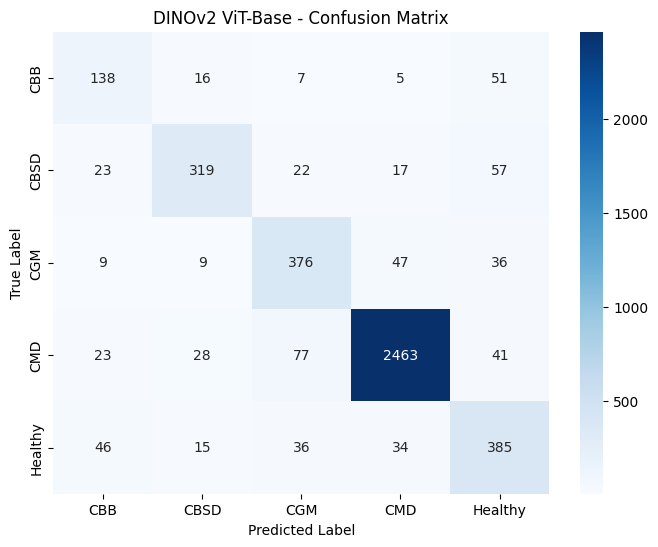

In [78]:
train_transform, val_transform = get_transforms(img_size=224)
CHECKPOINT_DIR="/content/drive/MyDrive/Cassava_Project/checkpoints"


# 5. Դատալոդերների կառուցում (batch_size=32 իդեալական է ViT-ների համար)
train_loader, valid_loader = get_dataloaders(
    train_df=train_df,
    val_df=val_df,
    img_dir=IMG_DIR,
    img_size=224,     # Քո ուզած չափսը DINOv2-ի համար
    batch_size=32,    # ViT/DINOv2-ի համար 32-ը շատ լավ է
    num_workers=2
)

print(" DINOv2 Դատալոդերները պատրաստ են (224x224)!")

# 6. Մոդելի, Loss-ի, Optimizer-ի և Scheduler-ի ինիցիալիզացիա
model_name = "DINOv2 ViT-Base"
model = DINOv2Cassava(num_classes=5, freeze_backbone=False).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-6)

checkpoint_path = os.path.join(CHECKPOINT_DIR, "dinov2_vitb14_best.pth")

# 7. Չեքփոինթի ստուգում և թրեյնինգ
if os.path.exists(checkpoint_path):
    print(f" {model_name}-ի Checkpoint-ը գտնվեց։ Բեռնում ենք պահված քաշերը...")
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.eval()
    print(" Մոդելը հաջողությամբ բեռնվեց:")
else:
    print(f" Checkpoint-ը չգտնվեց։ Սկսում ենք {model_name}-ի վարժեցումը...")
    history = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=valid_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        epochs=5,
        scheduler=scheduler,
        save_path=checkpoint_path,
        use_amp=True,
        monitor="val_acc"
    )

# 8. Վերջնական գնահատում
evaluate_model(
    model=model,
    val_loader=valid_loader,
    device=device,
    model_name=model_name
)

In [ ]:
import importlib
import model


importlib.reload(model)

# Resnet

In [ ]:
from dataset import get_dataloaders
from model import ResNet50Cassava

from utils import verify_transfer_setup
from train import train_model
from utils import evaluate_model
import torch.nn as nn

 ResNet50 Դատալոդերները պատրաստ են (384x384)!
 ResNet50-ի Checkpoint-ը գտնվեց։ Բեռնում ենք քաշերը...
 Մոդելը հաջողությամբ բեռնվեց:
=== ResNet50 ===
Output shape: torch.Size([1, 5]) (պետք է լինի [1, 5])
Trainable params: 23,518,277 / 23,518,277 (100.00%)
✅ Setup-ը ճիշտ է


=== RESNET50 CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

         CBB     0.3811    0.5392    0.4466       217
        CBSD     0.5611    0.5137    0.5364       438
         CGM     0.5596    0.6394    0.5969       477
         CMD     0.9531    0.7880    0.8627      2632
     Healthy     0.4336    0.7151    0.5399       516

    accuracy                         0.7220      4280
   macro avg     0.5777    0.6391    0.5965      4280
weighted avg     0.7775    0.7220    0.7397      4280

 Confusion matrix saved to: /content/drive/MyDrive/Cassava_Project/plots/resnet50_confusion_matrix.png


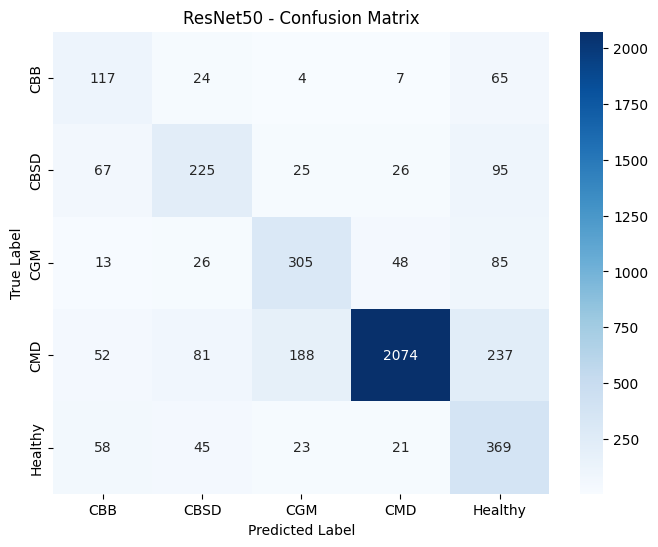

In [75]:
CHECKPOINT_DIR="/content/drive/MyDrive/Cassava_Project/checkpoints"
train_loader, valid_loader = get_dataloaders(
  train_df=train_df,
  val_df=val_df,
  img_dir=IMG_DIR,
  img_size=384,
  batch_size=16, # 384x384 չափսի համար 16-ը հարմար է հիշողության (VRAM) համար
  num_workers=2
)
print(" ResNet50 Դատալոդերները պատրաստ են (384x384)!")

# 5. Մոդելի, Loss-ի, Optimizer-ի և Scheduler-ի ինիցիալիզացիա
model_name = "ResNet50"
model = ResNet50Cassava(num_classes=5, freeze_backbone=False).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-6)

checkpoint_path = os.path.join(CHECKPOINT_DIR, "resnet50_head_best.pth")

if os.path.exists(checkpoint_path):
  print(f" {model_name}-ի Checkpoint-ը գտնվեց։ Բեռնում ենք քաշերը...")
  model.load_state_dict(torch.load(checkpoint_path, map_location=device))
  model.eval()
  print(" Մոդելը հաջողությամբ բեռնվեց:")
else:
  print(f"Checkpoint-ը չգտնվեց։ Սկսում ենք {model_name}-ի վարժեցումը...")
  history = train_model(
  model=model,
  train_loader=train_loader,
  val_loader=valid_loader,
  criterion=criterion,
  optimizer=optimizer,
  device=device,
  epochs=5,
  cheduler=scheduler,
  save_path=checkpoint_path,
  use_amp=True,
  monitor="val_acc"
 )

verify_transfer_setup(model, model_name, device=device)

# 7. Վերջնական գնահատում և մատրիցի պահպանում
evaluate_model(
  model=model,
  val_loader=valid_loader,
  device=device,
  model_name=model_name,
  save_dir="/content/drive/MyDrive/Cassava_Project/plots"
)

# Resnet Fine-tuned

In [ ]:
from utils import  calculate_class_weights
from model import EfficientNetV2SCassava
import numpy as np


In [76]:
import os
import torch
import torch.optim as optim
from utils import save_history_json, load_history
from model import unfreeze_last_block

RESNET_FINETUNED_PATH = '/content/drive/MyDrive/Cassava_Project/checkpoints/resnet50_finetuned_best.pth'
history_dir = '/content/drive/MyDrive/Cassava_Project/history'
finetune_history_path = os.path.join(history_dir, 'resnet50_finetuned_history.json')
full_history_path = os.path.join(history_dir, 'resnet50_full_history.json')

if os.path.exists(RESNET_FINETUNED_PATH):
    print(f"Fine-tuned չեքփոինթը գտնվեց։ Բեռնում ենք քաշերը...")

    checkpoint_state = torch.load(RESNET_FINETUNED_PATH, map_location=device)

    # Ճշգրտում ենք բանալիները (Prefix-ները և վերջին fc շերտը)
    fixed_state_dict = {}
    for k, v in checkpoint_state.items():
        new_key = k if k.startswith("resnet.") else "resnet." + k

        if new_key == "resnet.fc.weight":
            fixed_state_dict["resnet.fc.1.weight"] = v
        elif new_key == "resnet.fc.bias":
            fixed_state_dict["resnet.fc.1.bias"] = v
        else:
            fixed_state_dict[new_key] = v

    model.load_state_dict(fixed_state_dict)
    model.eval()
    print("Fine-tuned ResNet50 մոդելը հաջողությամբ բեռնվեց:")

    if os.path.exists(finetune_history_path):
        history_resnet_finetune = load_history(finetune_history_path)
        print("Fine-tune history-ն հաջողությամբ բեռնվեց ֆայլից:")
    else:
        print("Fine-tune history JSON ֆայլը չգտնվեց:")
        history_resnet_finetune = {}
else:
    print("Fine-tuned չեքփոինթը չգտնվեց։ Սկսում ենք fine-tuning-ը...")

    # 1. Բացում ենք վերջին բլոկը ուտիլիսից
    resnet_model = unfreeze_last_block(model)

    # 2. Ստեղծում ենք ֆայնթյունինգի օպտիմիզատորը
    finetune_optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, resnet_model.parameters()),
        lr=1e-5, weight_decay=1e-4
    )

    # 3. Գործարկում ենք թրեյնինգը
    history_resnet_finetune = train_model(
        model=resnet_model,
        train_loader=train_loader,
        val_loader=valid_loader,
        criterion=criterion,
        optimizer=finetune_optimizer,
        device=device,
        epochs=5,
        save_path=RESNET_FINETUNED_PATH,
        use_amp=True,
        monitor="val_acc"
    )

    # Պահպանում ենք առանձին ֆայնթյունի հիսթրին
    save_history_json(history_resnet_finetune, os.path.join(history_dir, 'resnet50_finetuned_history.json'))

# 4. Վերջում միավորում ենք հեդի և ֆայնթյունի պատմությունները ու պահպանում մեկ ընդհանուր ֆայլում
history_resnet_head = load_history(os.path.join(history_dir, 'resnet50_head_history.json'))

resnet_full_history = {
    "head_only": history_resnet_head,
    "finetuned": history_resnet_finetune
}

save_history_json(resnet_full_history, full_history_path)
print("ResNet50 ամբողջական պատմությունը հաջողությամբ միավորվեց և պահպանվեց:")

Fine-tuned չեքփոինթը գտնվեց։ Բեռնում ենք քաշերը...
Fine-tuned ResNet50 մոդելը հաջողությամբ բեռնվեց:
✅ History loaded from JSON: /content/drive/MyDrive/Cassava_Project/history/resnet50_finetuned_history.json
Fine-tune history-ն հաջողությամբ բեռնվեց ֆայլից:
✅ History-ն ապահով պահպանվեց Drive-ում: /content/drive/MyDrive/Cassava_Project/history/resnet50_full_history.json
ResNet50 ամբողջական պատմությունը հաջողությամբ միավորվեց և պահպանվեց:


Plot saved successfully to /content/drive/MyDrive/Cassava_Project/history/resnet50_finetune_curves.png


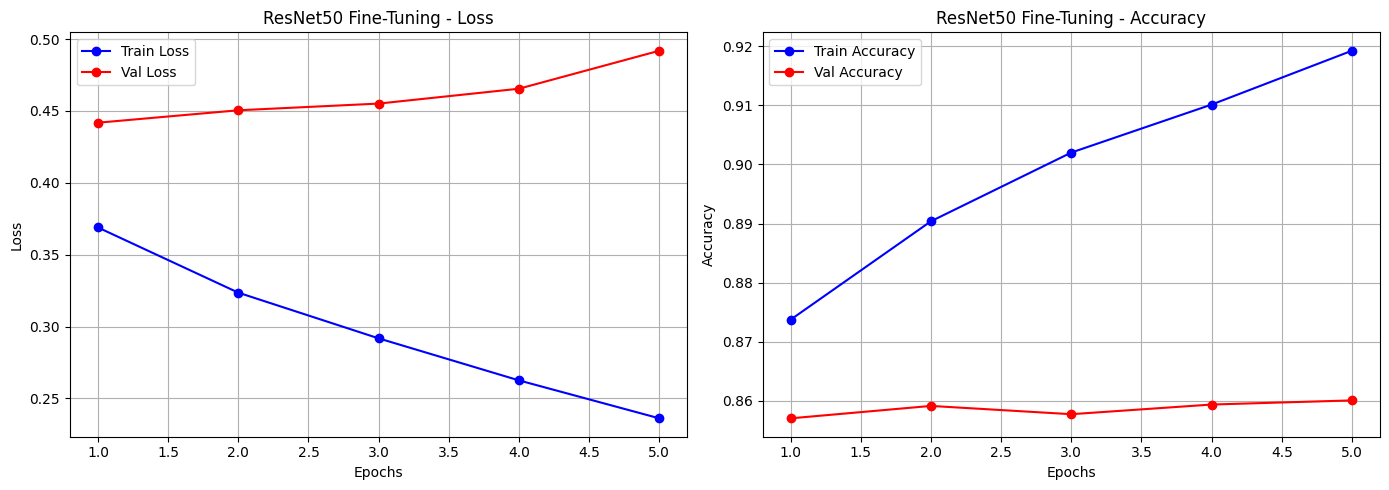

In [77]:
import os
import matplotlib.pyplot as plt
from utils import plot_training_curves, load_history

#Loading histories
head_history_path = os.path.join(history_dir, 'resnet50_head_history.json')
finetune_history_path = os.path.join(history_dir, 'resnet50_finetuned_history.json')
history_resnet_head = load_history(head_history_path) if os.path.exists(head_history_path) else {}

# If history_resnet_finetune using
if 'history_resnet_finetune' not in locals() or not history_resnet_finetune:
    if os.path.exists(finetune_history_path):
        history_resnet_finetune = load_history(finetune_history_path)
    else:
        history_resnet_finetune = {}

if history_resnet_finetune:
    plot_training_curves(
        train_losses=history_resnet_finetune.get('train_loss', []),
        val_losses=history_resnet_finetune.get('val_loss', []),
        train_accs=history_resnet_finetune.get('train_acc', history_resnet_finetune.get('train_accuracy', [])),
        val_accs=history_resnet_finetune.get('val_acc', history_resnet_finetune.get('val_accuracy', [])),
        title="ResNet50 Fine-Tuning",
        save_path=os.path.join(history_dir, 'resnet50_finetune_curves.png')
    )

# Head + Fine-tune
if history_resnet_head and history_resnet_finetune:
    full_train_loss = history_resnet_head.get('train_loss', []) + history_resnet_finetune.get('train_loss', [])
    full_val_loss = history_resnet_head.get('val_loss', []) + history_resnet_finetune.get('val_loss', [])

    # Ստուգում ենք բանալու անունը (acc թե accuracy)
    head_train_acc = history_resnet_head.get('train_acc', history_resnet_head.get('train_accuracy', []))
    fine_train_acc = history_resnet_finetune.get('train_acc', history_resnet_finetune.get('train_accuracy', []))
    full_train_acc = head_train_acc + fine_train_acc

    head_val_acc = history_resnet_head.get('val_acc', history_resnet_head.get('val_accuracy', []))
    fine_val_acc = history_resnet_finetune.get('val_acc', history_resnet_finetune.get('val_accuracy', []))
    full_val_acc = head_val_acc + fine_val_acc

    # full curves
    plot_training_curves(
        train_losses=full_train_loss,
        val_losses=full_val_loss,
        train_accs=full_train_acc,
        val_accs=full_val_acc,
        title="ResNet50 Full Training (Head + Fine-Tune)",
        save_path=os.path.join(history_dir, 'resnet50_full_curves.png')
    )

# EfficentNet

In [ ]:
from model import EfficientNetV2SCassava
from utils import calculate_class_weights, freeze_backbone

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


✅ EfficientNetV2-S Դատալոդերները պատրաստ են (384x384)!
Class weights: tensor([3.9349, 1.9551, 1.7933, 0.3252, 1.6610], device='cuda:0')
🎯 EfficientNetV2-S-ի Checkpoint-ը գտնվեց։ Բեռնում ենք քաշերը...
✅ Մոդելը հաջողությամբ բեռնվեց:
=== EfficientNetV2-S ===
Output shape: torch.Size([1, 5]) (պետք է լինի [1, 5])
Trainable params: 20,183,893 / 20,183,893 (100.00%)
✅ Setup-ը ճիշտ է


=== EFFICIENTNETV2-S CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

         CBB     0.3249    0.5899    0.4190       217
        CBSD     0.4286    0.4452    0.4367       438
         CGM     0.4148    0.5765    0.4825       477
         CMD     0.9416    0.7162    0.8136      2632
     Healthy     0.4178    0.6202    0.4992       516

    accuracy                         0.6549      4280
   macro avg     0.5055    0.5896    0.5302      4280
weighted avg     0.7359    0.6549    0.6802      4280

 Confusion matrix saved to: /content/drive/MyDrive/Cassava_Project/plots/efficientn

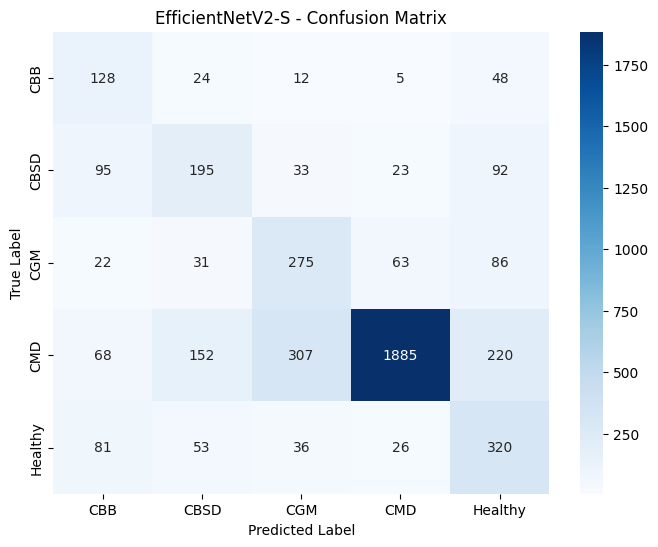

In [74]:
CHECKPOINT_DIR = "/content/drive/MyDrive/Cassava_Project/checkpoints"

train_loader, valid_loader = get_dataloaders(
    train_df=train_df,
    val_df=val_df,
    img_dir=IMG_DIR,
    img_size=384,
    batch_size=16,    # 384x384 չափսի համար 16-ը հարմար է հիշողության (VRAM) համար
    num_workers=2
)
print("✅ EfficientNetV2-S Դատալոդերները պատրաստ են (384x384)!")

# ⚖️ Հաշվարկում ենք դասերի կշիռները ճիշտ ֆունկցիայով
class_weights = calculate_class_weights(train_df, label_col='label').to(device)
print("Class weights:", class_weights)

# 5. Մոդելի, Loss-ի (կշռված), Optimizer-ի և Scheduler-ի ինիցիալիզացիա
model_name = "EfficientNetV2-S"
model = EfficientNetV2SCassava(num_classes=5, freeze_backbone=False).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-6)

checkpoint_path = os.path.join(CHECKPOINT_DIR, "efficientnet_v2_s_head_best.pth")

if os.path.exists(checkpoint_path):
    print(f"🎯 {model_name}-ի Checkpoint-ը գտնվեց։ Բեռնում ենք քաշերը...")
    state_dict = torch.load(checkpoint_path, map_location=device)

    # Շտկում ենք բանալիների անհամապատասխանությունը
    new_state_dict = {}
    for k, v in state_dict.items():
        if not k.startswith("net."):
            k = f"net.{k}"
        if "classifier.1.weight" in k:
            k = k.replace("classifier.1.weight", "classifier.1.1.weight")
        elif "classifier.1.bias" in k:
            k = k.replace("classifier.1.bias", "classifier.1.1.bias")
        new_state_dict[k] = v

    model.load_state_dict(new_state_dict, strict=True)
    model.eval()
    print("✅ Մոդելը հաջողությամբ բեռնվեց:")
else:
    print(f"⚠️ Checkpoint-ը չգտնվեց։ Սկսում ենք {model_name}-ի վարժեցումը...")
    history = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=valid_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        epochs=5,
        scheduler=scheduler,
        save_path=checkpoint_path,
        use_amp=True,
        monitor="val_acc"
    )

verify_transfer_setup(model, model_name, device=device)

# 7. Վերջնական գնահատում և մատրիցի պահպանում
evaluate_model(
    model=model,
    val_loader=valid_loader,
    device=device,
    model_name=model_name,
    save_dir="/content/drive/MyDrive/Cassava_Project/plots"
)

# Effnet Fine tuned


In [ ]:
import os
import torch
import torch.optim as optim
import torch.nn as nn
from utils import save_history_json, load_history
from model import EfficientNetV2SCassava, unfreeze_last_block
from train import train_model

# 0. Մոդելի ինիցիալիզացիա
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
effnet_model = EfficientNetV2SCassava(num_classes=5, freeze_backbone=False).to(device)

# 1. Ուղիների սահմանում
EFFNET_HEAD_PATH = '/content/drive/MyDrive/Cassava_Project/checkpoints/efficientnet_v2_s_head_best2.pth'
EFFNET_FINETUNE_PATH = '/content/drive/MyDrive/Cassava_Project/checkpoints/efficientnet_v2_s_finetuned_best.pth'

history_dir = '/content/drive/MyDrive/Cassava_Project/history'
finetune_history_path = os.path.join(history_dir, 'efficientnet_v2_s_finetuned_history.json')
full_history_path = os.path.join(history_dir, 'efficientnet_v2_s_full_history.json')

os.makedirs(os.path.dirname(EFFNET_FINETUNE_PATH), exist_ok=True)
os.makedirs(history_dir, exist_ok=True)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# ----------------------------------------------------
# CHECKPOINT-Ի ՍՏՈՒԳՈՒՄ ԵՎ FINE-TUNING
# ----------------------------------------------------

if os.path.exists(EFFNET_FINETUNE_PATH):
    print(f"🎯 Fine-tuned EfficientNetV2-S չեքփոինթը գտնվեց։ Բեռնում ենք քաշերը...")

    state_dict = torch.load(EFFNET_FINETUNE_PATH, map_location=device)

    new_state_dict = {}
    for k, v in state_dict.items():
        if not k.startswith("net."):
            k = f"net.{k}"
        new_state_dict[k] = v

    effnet_model.load_state_dict(new_state_dict)
    effnet_model.eval()
    print("✅ Fine-tuned EfficientNetV2-S մոդելը հաջողությամբ բեռնվեց:")

    if os.path.exists(finetune_history_path):
        history_effnet_finetune = load_history(finetune_history_path)
        print("✅ Fine-tune history-ն հաջողությամբ բեռնվեց JSON-ից:")
    else:
        print("⚠️ Fine-tune history JSON ֆայլը չգտնվեց:")
        history_effnet_finetune = {}

else:
    print("⚠️ Fine-tuned չեքփոինթը չգտնվեց։ Սկսում ենք Fine-Tuning-ը Head Checkpoint-ի հիման վրա...")

    # 1. Բեռնում ենք Head-only չեքփոինթը
    if os.path.exists(EFFNET_HEAD_PATH):
        print(f"📥 Բեռնում ենք Head-only չեքփոինթը՝ {EFFNET_HEAD_PATH}")
        head_state_dict = torch.load(EFFNET_HEAD_PATH, map_location=device)

        new_state_dict = {}
        for k, v in head_state_dict.items():
            if not k.startswith("net."):
                k = f"net.{k}"
            if "classifier.1.weight" in k and "classifier.1.1.weight" not in k:
                k = k.replace("classifier.1.weight", "classifier.1.1.weight")
            elif "classifier.1.bias" in k and "classifier.1.1.bias" not in k:
                k = k.replace("classifier.1.bias", "classifier.1.1.bias")
            new_state_dict[k] = v

        effnet_model.load_state_dict(new_state_dict, strict=True)
        print("✅ Head-only կշիռները հաջողությամբ բեռնվեցին մոդելի մեջ:")
    else:
        print("⚠️ Head-only չեքփոինթը չգտնվեց, Fine-tuning-ը կսկսվի ընթացիկ մոդելից:")

    # 2. Ապասառեցնում ենք շերտերը fine-tuning-ի համար
    effnet_model = unfreeze_last_block(effnet_model)

    # 3. Optimizers
    finetune_optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, effnet_model.parameters()),
        lr=1e-5,
        weight_decay=1e-4
    )

    print("\n🚀 STARTING FINE-TUNING STAGE 🚀")

    # 4. Training
    history_effnet_finetune = train_model(
        model=effnet_model,
        train_loader=train_loader,
        val_loader=valid_loader,
        criterion=criterion,
        optimizer=finetune_optimizer,
        device=device,
        epochs=5,
        save_path=EFFNET_FINETUNE_PATH,
        use_amp=True,
        monitor="val_acc"
    )

    # 💾 🎯 ԱՅՍՏԵՂ ՊԱՀՈՒՄ ԵՆՔ FINE-TUNED .PTH-Ը DRIVE-ՈՒՄ
    torch.save(effnet_model.state_dict(), EFFNET_FINETUNE_PATH)
    print(f"✅ Fine-tuned մոդելի կշիռները պահպանվեցին Drive-ում: {EFFNET_FINETUNE_PATH}")

    # 5. History Saving
    save_history_json(history_effnet_finetune, finetune_history_path)

    effnet_full_history = {
        "finetuned": history_effnet_finetune
    }
    save_history_json(effnet_full_history, full_history_path)
    print("✅ Fine-tuning-ի history-ն պահպանվեց JSON-ում:")

⚠️ Fine-tuned չեքփոինթը չգտնվեց։ Սկսում ենք Fine-Tuning-ը Head Checkpoint-ի հիման վրա...
📥 Բեռնում ենք Head-only չեքփոինթը՝ /content/drive/MyDrive/Cassava_Project/checkpoints/efficientnet_v2_s_head_best2.pth
✅ Head-only կշիռները հաջողությամբ բեռնվեցին մոդելի մեջ:
🔓 EfficientNet-ի վերջին 2 բլոկները և classifier-ը ապաբլոկավորվեցին fine-tuning-ի համար:

🚀 STARTING FINE-TUNING STAGE 🚀
🚀 Starting Training [FP16 (AMP)] | Monitoring: val_acc...


/content/drive/MyDrive/Cassava_Project/ֆայլեր/train.py:45: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() if use_amp else None


Epoch 1/5 [Train]:   0%|          | 0/1069 [00:00<?, ?it/s]

/content/drive/MyDrive/Cassava_Project/ֆայլեր/train.py:72: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/content/drive/MyDrive/Cassava_Project/ֆայլեր/train.py:114: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [1/5] (2993.9s) | Train Loss: 0.7614 - Train Acc: 0.8251 | Val Loss: nan - Val Acc: 0.8493 --> Saved Best Checkpoint (val_acc: 0.8493)


...

Epoch [3/5] (384.3s) | Train Loss: 0.6658 - Train Acc: 0.8736 | Val Loss: 0.7172 - Val Acc: 0.8736 --> Saved Best Checkpoint (val_acc: 0.8736)


Epoch 4/5 [Train]:   0%|          | 0/1069 [00:00<?, ?it/s]

Epoch [4/5] (382.6s) | Train Loss: 0.6479 - Train Acc: 0.8844 | Val Loss: nan - Val Acc: 0.8762 --> Saved Best Checkpoint (val_acc: 0.8762)


Epoch 5/5 [Train]:   0%|          | 0/1069 [00:00<?, ?it/s]

Epoch [5/5] (382.1s) | Train Loss: 0.6232 - Train Acc: 0.8958 | Val Loss: nan - Val Acc: 0.8657
✅ Fine-tuned մոդելի կշիռները պահպանվեցին Drive-ում: /content/drive/MyDrive/Cassava_Project/checkpoints/efficientnet_v2_s_finetuned_best.pth
✅ History-ն ապահով պահպանվեց Drive-ում: /content/drive/MyDrive/Cassava_Project/history/efficientnet_v2_s_finetuned_history.json
✅ History-ն ապահով պահպանվեց Drive-ում: /content/drive/MyDrive/Cassava_Project/history/efficientnet_v2_s_full_history.json
✅ Fine-tuning-ի history-ն պահպանվեց JSON-ում:


In [70]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from train import train_model
from utils import save_history_json, load_history

EFFNET_PATH = '/content/drive/MyDrive/Cassava_Project/checkpoints/efficientnet_v2_s_head_best2.pth'
EFFNET_FINETUNED_PATH = '/content/drive/MyDrive/Cassava_Project/checkpoints/efficientnet_v2_s_finetuned_best.pth'

history_dir = '/content/drive/MyDrive/Cassava_Project/history'
head_history_path = os.path.join(history_dir, 'efficientnet_v2_s_head_history.json')
finetune_history_path = os.path.join(history_dir, 'efficientnet_v2_s_finetuned_history.json')
full_history_path = os.path.join(history_dir, 'efficientnet_v2_s_full_history.json')

os.makedirs(history_dir, exist_ok=True)
os.makedirs(os.path.dirname(EFFNET_FINETUNED_PATH), exist_ok=True)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

if os.path.exists(EFFNET_FINETUNED_PATH):
    print(" Fine-tuned EfficientNet checkpoint-ը գտնվեց։ Բեռնում ենք քաշերը...")
    checkpoint_state = torch.load(EFFNET_FINETUNED_PATH, map_location=device)
    effnet_model.load_state_dict(checkpoint_state)
    effnet_model.eval()
    print(" Fine-tuned EfficientNetV2-S մոդելը հաջողությամբ բեռնվեց:")

    if os.path.exists(finetune_history_path):
        history_effnet_finetune = load_history(finetune_history_path)
        print(" Fine-tune history-ն հաջողությամբ բեռնվեց ֆայլից:")
    else:
        print(" Fine-tune history JSON ֆայլը չգտնվեց:")
        history_effnet_finetune = {}
else:
    print(" Fine-tuned checkpoint-ը չգտնվեց։ Սկսում ենք fine-tuning-ը...")

    # 1. Ապասառեցնում ենք վերջին բլոկները (կամ ամբողջ backbone-ը փոքր LR-ով)
    target_net = effnet_model.net if hasattr(effnet_model, 'net') else effnet_model
    for param in target_net.parameters():
        param.requires_grad = True

    # 2. Ստեղծում ենք ֆայնթյունինգի օպտիմիզատորը (փոքր learning rate-ով)
    finetune_optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, effnet_model.parameters()),
        lr=1e-5,
        weight_decay=1e-4
    )

    # 3. Գործարկում ենք թրեյնինգը
    history_effnet_finetune = train_model(
        model=effnet_model,
        train_loader=train_loader,
        val_loader=valid_loader,
        criterion=criterion,
        optimizer=finetune_optimizer,
        device=device,
        epochs=5,
        save_path=EFFNET_FINETUNED_PATH,
        use_amp=True,
        monitor="val_acc"
    )

    # Պահպանում ենք առանձին fine-tune պատմությունը
    save_history_json(history_effnet_finetune, finetune_history_path)

# 4. Միավորում ենք Stage 1 (head) և Stage 2 (finetuned) պատմությունները
history_effnet_head = load_history(head_history_path) if os.path.exists(head_history_path) else {}

effnet_full_history = {
    "head_only": history_effnet_head,
    "finetuned": history_effnet_finetune
}

save_history_json(effnet_full_history, full_history_path)
print(" EfficientNetV2-S ամբողջական պատմությունը հաջողությամբ միավորվեց և պահպանվեց:")

 Fine-tuned EfficientNet checkpoint-ը գտնվեց։ Բեռնում ենք քաշերը...
 Fine-tuned EfficientNetV2-S մոդելը հաջողությամբ բեռնվեց:
✅ History loaded from JSON: /content/drive/MyDrive/Cassava_Project/history/efficientnet_v2_s_finetuned_history.json
 Fine-tune history-ն հաջողությամբ բեռնվեց ֆայլից:
✅ History-ն ապահով պահպանվեց Drive-ում: /content/drive/MyDrive/Cassava_Project/history/efficientnet_v2_s_full_history.json
 EfficientNetV2-S ամբողջական պատմությունը հաջողությամբ միավորվեց և պահպանվեց:


Plot saved successfully to /content/drive/MyDrive/Cassava_Project/history/efficientnet_v2_s_finetune_curves.png


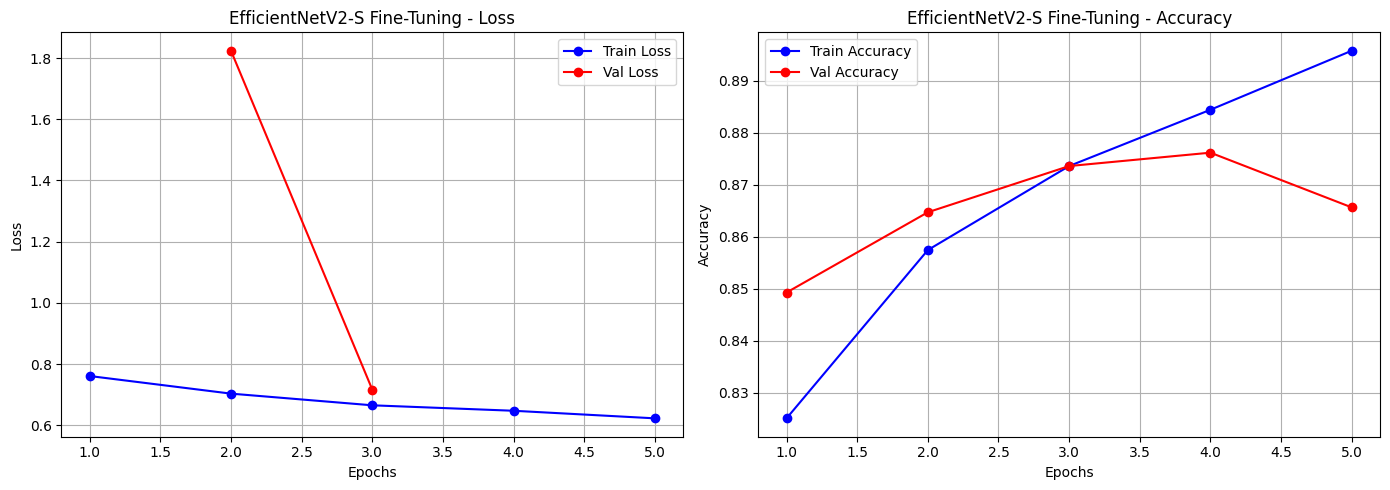

In [71]:
import os
import matplotlib.pyplot as plt
from utils import plot_training_curves, load_history

head_history_path = os.path.join(history_dir, 'efficientnet_v2_s_head_history.json')
finetune_history_path = os.path.join(history_dir, 'efficientnet_v2_s_finetuned_history.json')

history_effnet_head = load_history(head_history_path) if os.path.exists(head_history_path) else {}

# Ստուգում ենք փոփոխականի առկայությունը memory-ում կամ բեռնում ֆայլից
if 'history_effnet_finetune' not in locals() or not history_effnet_finetune:
    if os.path.exists(finetune_history_path):
        history_effnet_finetune = load_history(finetune_history_path)
    else:
        history_effnet_finetune = {}

# 1. Գրաֆիկ միայն Fine-Tuning փուլի համար
if history_effnet_finetune:
    plot_training_curves(
        train_losses=history_effnet_finetune.get('train_loss', []),
        val_losses=history_effnet_finetune.get('val_loss', []),
        train_accs=history_effnet_finetune.get('train_acc', history_effnet_finetune.get('train_accuracy', [])),
        val_accs=history_effnet_finetune.get('val_acc', history_effnet_finetune.get('val_accuracy', [])),
        title="EfficientNetV2-S Fine-Tuning",
        save_path=os.path.join(history_dir, 'efficientnet_v2_s_finetune_curves.png')
    )

# 2. Գրաֆիկ Head + Fine-Tune միացյալ փուլերի համար
if history_effnet_head and history_effnet_finetune:
    full_train_loss = history_effnet_head.get('train_loss', []) + history_effnet_finetune.get('train_loss', [])
    full_val_loss = history_effnet_head.get('val_loss', []) + history_effnet_finetune.get('val_loss', [])

    head_train_acc = history_effnet_head.get('train_acc', history_effnet_head.get('train_accuracy', []))
    fine_train_acc = history_effnet_finetune.get('train_acc', history_effnet_finetune.get('train_accuracy', []))
    full_train_acc = head_train_acc + fine_train_acc

    head_val_acc = history_effnet_head.get('val_acc', history_effnet_head.get('val_accuracy', []))
    fine_val_acc = history_effnet_finetune.get('val_acc', history_effnet_finetune.get('val_accuracy', []))
    full_val_acc = head_val_acc + fine_val_acc

    plot_training_curves(
        train_losses=full_train_loss,
        val_losses=full_val_loss,
        train_accs=full_train_acc,
        val_accs=full_val_acc,
        title="EfficientNetV2-S Full Training (Head + Fine-Tune)",
        save_path=os.path.join(history_dir, 'efficientnet_v2_s_full_curves.png')
    )

In [ ]:
from google.colab import drive
import os

# Եթե նախորդ կապից մնացորդ կա, անջատում ենք
if os.path.exists('/content/drive'):
    try:
        drive.flush_and_unmount()
    except:
        pass

# Նորից ենք միացնում
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:

import glob

# Որոնում ենք բոլոր Cassava_Project անունով պանակները միացված Drive-ում
found_paths = glob.glob('/content/drive/**/Cassava_Project', recursive=True)
print("Գտնված ճանապարհները՝", found_paths)

Գտնված ճանապարհները՝ ['/content/drive/MyDrive/Cassava_Project']


In [ ]:
import sys
import os

eval_path = '/content/drive/MyDrive/Cassava_Project/Ֆայլեր'
if eval_path not in sys.path:
    sys.path.append(eval_path)

In [ ]:
import sys

# Հեռացնում ենք հին քեշավորված մոդուլները, որպեսզի կարդա ճիշտ տեղից
for mod in ['utils', 'dataset', 'evaluate']:
    if mod in sys.modules:
        del sys.modules[mod]

print("Մոդուլների քեշը մաքրվեց։")

Մոդուլների քեշը մաքրվեց։


In [ ]:
import shutil
import os
import sys

# 1. Պատճենում ենք ամբողջ նախագիծը տեղական /content պանակ
source_path = '/content/drive/.shortcut-targets-by-id/1ti7m-DT_NHuyo1h_maUZMvfSdGXOpslV/Cassava_Project'
dest_path = '/content/Cassava_Project'

if not os.path.exists(dest_path):
    shutil.copytree(source_path, dest_path)
    print("Նախագիծը հաջողությամբ պատճենվեց տեղական հիշողություն:")
else:
    print("Նախագիծն արդեն պատճենված է:")

# 2. Տեղափոխվում ենք Ֆայլեր պանակ
target_dir = '/content/Cassava_Project/ֆայլեր'
os.chdir(target_dir)

if target_dir not in sys.path:
    sys.path.insert(0, target_dir)

print("Ընթացիկ պանակը՝", os.getcwd())

Նախագիծն արդեն պատճենված է:
Ընթացիկ պանակը՝ /content/Cassava_Project/ֆայլեր


In [ ]:
import sys
import os

eval_path = '/content/drive/.shortcut-targets-by-id/1ti7m-DT_NHuyo1h_maUZMvfSdGXOpslV/Cassava_Project/ֆայլեր'
if eval_path not in sys.path:
    sys.path.insert(0, eval_path)
os.chdir(eval_path)

# Ներմուծում ենք ֆունկցիաները
from evaluate import (
    run_cassava_evaluation,
    plot_model_results,
    finalize_best_model,
    compute_predictions,
    plot_misclassified_images,
    plot_random_validation_samples
)

print("Ներմուծումն հաջողվեց։ Սկսում ենք գնահատումը...")

# Գործարկում ենք գնահատումը
results_df = run_cassava_evaluation()
print(results_df)

ImportError: cannot import name 'get_metrics' from 'utils' (/content/drive/.shortcut-targets-by-id/1ti7m-DT_NHuyo1h_maUZMvfSdGXOpslV/Cassava_Project/ֆայլեր/utils.py)

In [ ]:
from evaluate import run_cassava_evaluation, plot_model_results, finalize_best_model, compute_predictions, plot_misclassified_images, plot_random_validation_samples

ModuleNotFoundError: No module named 'evaluate'

In [ ]:
# import os
# import torch
# import pandas as pd
# from utils import get_metrics
# from dataset import CassavaPyTorchDataset, get_dataloaders
# from model import BaselineCNN, ResNet50Cassava, EfficientNetV2SCassava, DINOv2Cassava
# from augmentations import get_transforms

# # 1. Հիմնական ուղիների և սարքավորման ստուգում
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print(f"Using device: {device}")

# NUM_CLASSES = 5
# MODEL_SAVE_DIR = '/content/drive/MyDrive/Cassava_Project/checkpoints'
# IMAGES_DIR = 'cassava_data/train_images'


# CNN_PATH = os.path.join(MODEL_SAVE_DIR, 'baseline_cnn_best.pth')
# RESNET_FINETUNED_PATH = os.path.join(MODEL_SAVE_DIR, 'resnet50_finetuned_best.pth')
# EFFNET_PATH = os.path.join(MODEL_SAVE_DIR, 'efficientnet_v2_s_head_best.pth')
# best_dino_path = os.path.join(MODEL_SAVE_DIR, 'dinov2_vitb14_best.pth')

# # 2. Մոդելների ստեղծում (Instantiation)
# baseline_model = BaselineCNN(num_classes=NUM_CLASSES).to(device)
# dino_model = DINOv2Cassava(num_classes=NUM_CLASSES, freeze_backbone=True).to(device)
# resnet_model = ResNet50Cassava(num_classes=NUM_CLASSES, freeze_backbone=True).to(device)
# effnet_model = EfficientNetV2SCassava(num_classes=NUM_CLASSES, freeze_backbone=True).to(device)

# # 2. Բեռնում ենք Baseline CNN
# baseline_model.load_state_dict(torch.load(CNN_PATH, map_location=device))

# # 3. ResNet50-ի բեռնում .items()-ով
# resnet_state_dict = torch.load(RESNET_FINETUNED_PATH, map_location=device)
# if not any(k.startswith('resnet.') for k in resnet_state_dict.keys()):
#     resnet_state_dict = {f"resnet.{k}": v for k, v in resnet_state_dict.items()}
# resnet_model.load_state_dict(resnet_state_dict, strict=False)

# # 4. EfficientNet-ի բեռնում .items()-ով
# effnet_state_dict = torch.load(EFFNET_PATH, map_location=device)
# if not any(k.startswith('net.') for k in effnet_state_dict.keys()):
#     effnet_state_dict = {f"net.{k}": v for k, v in effnet_state_dict.items()}
# effnet_model.load_state_dict(effnet_state_dict, strict=False)

# # 5. DINOv2-ի բեռնում
# dino_model.load_state_dict(torch.load(best_dino_path, map_location=device), strict=False)

# print("✅ Մոդելների քաշերը հաջողությամբ բեռնվեցին:")



# with open('cassava_data/label_num_to_disease_map.json') as f:
#     import json
#     label_map = json.load(f)
# class_names = [label_map[str(i)] for i in range(NUM_CLASSES)]



# # 4. Մետրիկների հաշվում և հաշվետվության տպում `utils`-ից
# print("\n=== Baseline CNN ===")
# baseline_metrics = get_metrics(baseline_model, valid_loader, device, class_names)

# print("\n=== ResNet50 (fine-tuned) ===")
# resnet_metrics = get_metrics(resnet_model, valid_loader, device, class_names)

# print("\n=== EfficientNetV2-S (head-only) ===")
# effnet_metrics = get_metrics(effnet_model, valid_loader, device, class_names)









# # Loader-ների ստեղծում

# _, dinov2_valid_loader = get_dataloaders(
#     train_df=train_df,
#     val_df=val_df,
#     img_dir=IMAGES_DIR,
#     img_size=224,
#     batch_size=16
# )


# print("\n=== DINOv2Cassava ===")
# dino_metrics = get_metrics(dino_model, dinov2_valid_loader, device, class_names)

# # 5. Վերջնական համեմատական աղյուսակի կազմում և տպում
# results = {
#     "BaselineCNN": baseline_metrics,
#     "ResNet50": resnet_metrics,
#     "EfficientNetV2S": effnet_metrics,
#     "DINOv2Cassava": dino_metrics,
# }

# results_df = pd.DataFrame(results).T
# results_df = results_df[["accuracy", "macro_precision", "macro_recall", "macro_f1"]]

# print("\n=== Final Comparison Summary ===")
# print(results_df.round(5))